<a href="https://colab.research.google.com/github/j019/Practical-Machine-Learning/blob/main/Day13/Practice_time_series_LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# problem Statement

Given data of stock market daily price of one share

Do prediction on close values

In [12]:
import pandas as pd
df = pd.read_csv("/content/HistoricalQuotes.csv")

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253 entries, 0 to 252
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    253 non-null    object 
 1   close   253 non-null    float64
 2   volume  253 non-null    int64  
 3   open    253 non-null    float64
 4   high    253 non-null    float64
 5   low     253 non-null    float64
dtypes: float64(4), int64(1), object(1)
memory usage: 12.0+ KB


In [14]:
df['date'] = pd.to_datetime(df['date'],format="%d-%m-%Y")

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253 entries, 0 to 252
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    253 non-null    datetime64[ns]
 1   close   253 non-null    float64       
 2   volume  253 non-null    int64         
 3   open    253 non-null    float64       
 4   high    253 non-null    float64       
 5   low     253 non-null    float64       
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 12.0 KB


In [16]:
df.set_index('date', inplace=True)

In [17]:
df.sort_index(inplace=True)

In [18]:
df.head()

,close,volume,open,high,low
date,,,,,
2018-08-09,208.88,23389530,207.280,209.780,207.20
2018-08-10,207.53,24592460,207.360,209.100,206.67
2018-08-13,208.87,25864510,207.700,210.952,207.70
2018-08-14,209.75,20679270,210.155,210.560,208.26
2018-08-15,210.24,28595230,209.220,210.740,208.33


# why to convert date to datetime ? & why to set date as index ?

start date --> 9th aug 2018

end date --> 10th aug 2019

if you want to slice by month

ex. see the data of july 2019

In [19]:
df.loc['01-2019']

,close,volume,open,high,low
date,,,,,
2019-01-02,157.92,35637070,154.89,158.8500,154.2300
2019-01-03,142.19,91106840,143.98,145.7200,142.0000
2019-01-04,148.26,57423650,144.53,148.5499,143.8000
2019-01-07,147.93,54571440,148.70,148.8300,145.9000
2019-01-08,150.75,40622910,149.56,151.8200,148.5200
2019-01-09,153.31,45034370,151.29,154.5300,149.6300
2019-01-10,153.80,35661200,152.50,153.9700,150.8600
2019-01-11,152.29,26924630,152.88,153.7000,151.5100
2019-01-14,150.00,32018540,150.85,151.2700,149.2200


# Understand missing values

In time series missing value means missing records ( rows)  , means complete date / time is missing

In [20]:
df.isnull().sum() # Not going to show missing values

,0
close,0
volume,0
open,0
high,0
low,0


## Step 1 : find the frequency of records

Various frequencies supported by pandas

https://pandas.pydata.org/pandas-docs/stable/user_guide/timeseries.html#offset-aliases

In [21]:
df.head(10)

,close,volume,open,high,low
date,,,,,
2018-08-09,208.88,23389530,207.280,209.7800,207.200
2018-08-10,207.53,24592460,207.360,209.1000,206.670
2018-08-13,208.87,25864510,207.700,210.9520,207.700
2018-08-14,209.75,20679270,210.155,210.5600,208.260
2018-08-15,210.24,28595230,209.220,210.7400,208.330
2018-08-16,213.32,27595310,211.750,213.8121,211.470
2018-08-17,217.58,35034410,213.440,217.9500,213.160
2018-08-20,215.46,30149410,218.100,219.1800,215.110
2018-08-21,215.04,25682700,216.800,217.1900,214.025


## Step 2: use asfreq function in pandas and store result in new data frame

this function is going to check if all the time values ( dates / hrs / mins / months ) are present

if any time value is missing , then it creates a new row for that missing value and fills it with NaN

In [22]:
df_new = df.asfreq('B') # B -- > business day frequency

In [23]:
df.shape,df_new.shape

((253, 5), (262, 5))

In [24]:
df_new.isnull().sum()

,0
close,10
volume,10
open,10
high,10
low,10


In [25]:
df_daily = df.asfreq('D') # D --> calendar day frequency

In [26]:
df_daily.shape

(367, 5)

## Step 3 :: Fill the missing values ( Don't use median / mode / mean)

- what to use to fill ??

previous day (frontfill)  or next day value  (backfill)

In [27]:
df_new.fillna(method='ffill', inplace=True) # fill missing with previous days values

/tmp/ipykernel_1913/2357595627.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_new.fillna(method='ffill', inplace=True) # fill missing with previous days values


In [28]:
df_new.isnull().sum()

,0
close,0
volume,0
open,0
high,0
low,0


# Decompose the time series


Time series is made up of

- Trend -> moving average

average value of last few observations

ex. what is trend of last week sales , whats trend of last month share market ,etc

- Seasonality -> repeatition pattern

ex. seasonal sales of rain coat, sales on festivals ( diwali), rainy season, etc

- Residue / noise --> random value which cannot be modeled

This will always induce error so TS model never has 0 error


Two types of time series

- Additive

TS Value = Trend + Seasonality + noise

- Multiplicative

TS value = Trend * Seasonality * noise




## NOTE OF CAUTION :: ONLY use non missing value dates ... if any dates are missing in the data then following code will start giving ERROR

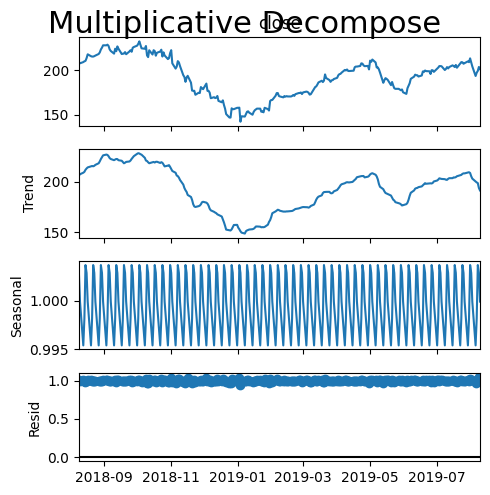

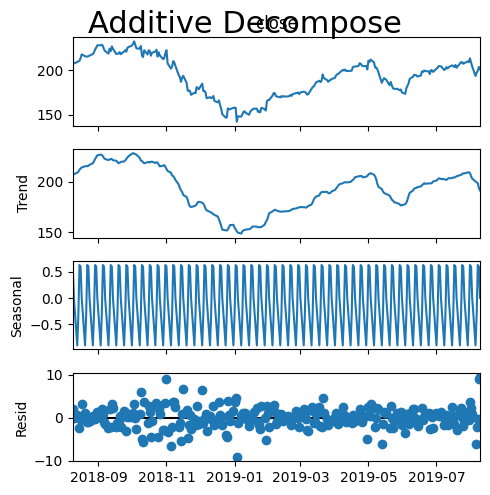

In [29]:
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from dateutil.parser import parse

# Multiplicative Decomposition
result_mul = seasonal_decompose(df_new['close'], model='multiplicative', extrapolate_trend='freq')

# Additive Decomposition
result_add = seasonal_decompose(df_new['close'], model='additive', extrapolate_trend='freq')

# Plot
plt.rcParams.update({'figure.figsize': (5,5)})
result_mul.plot().suptitle('Multiplicative Decompose', fontsize=22)
result_add.plot().suptitle('Additive Decompose', fontsize=22)
plt.show()

Note :: Simple method to detect is multiplicative or additive model

Compare the noise / residue of both models

The model which has repeatitions in residue that is wrong model

IN THIS CASE both models are working perfectly so choose any

# Apply regression for Time series Prediction

## Create the features

 how many ? --> you can do trial and error

 here we will consider 5

In [30]:
df_new.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 262 entries, 2018-08-09 to 2019-08-09
Freq: B
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   close   262 non-null    float64
 1   volume  262 non-null    float64
 2   open    262 non-null    float64
 3   high    262 non-null    float64
 4   low     262 non-null    float64
dtypes: float64(5)
memory usage: 12.3 KB


In [31]:
ts_data = df_new[['close']].copy()
ts_data.shape

(262, 1)

In [32]:
ts_data['close_t_1'] = ts_data['close'].shift(1) # shift one value below
ts_data['close_t_2'] = ts_data['close'].shift(2) # shift one value below
ts_data['close_t_3'] = ts_data['close'].shift(3) # shift one value below
ts_data['close_t_4'] = ts_data['close'].shift(4) # shift one value below
ts_data['close_t_5'] = ts_data['close'].shift(5) # shift one value below

In [33]:
ts_data.head(7)

,close,close_t_1,close_t_2,close_t_3,close_t_4,close_t_5
date,,,,,,
2018-08-09,208.88,NaN,NaN,NaN,NaN,NaN
2018-08-10,207.53,208.88,NaN,NaN,NaN,NaN
2018-08-13,208.87,207.53,208.88,NaN,NaN,NaN
2018-08-14,209.75,208.87,207.53,208.88,NaN,NaN
2018-08-15,210.24,209.75,208.87,207.53,208.88,NaN
2018-08-16,213.32,210.24,209.75,208.87,207.53,208.88
2018-08-17,217.58,213.32,210.24,209.75,208.87,207.53


In [34]:
ts_data.dropna(inplace=True)

In [35]:
ts_data.head()

,close,close_t_1,close_t_2,close_t_3,close_t_4,close_t_5
date,,,,,,
2018-08-16,213.32,210.24,209.75,208.87,207.53,208.88
2018-08-17,217.58,213.32,210.24,209.75,208.87,207.53
2018-08-20,215.46,217.58,213.32,210.24,209.75,208.87
2018-08-21,215.04,215.46,217.58,213.32,210.24,209.75
2018-08-22,215.05,215.04,215.46,217.58,213.32,210.24


In [36]:
ts_data.tail()

,close,close_t_1,close_t_2,close_t_3,close_t_4,close_t_5
date,,,,,,
2019-08-05,193.34,204.02,208.43,213.04,208.78,209.68
2019-08-06,197.00,193.34,204.02,208.43,213.04,208.78
2019-08-07,199.04,197.00,193.34,204.02,208.43,213.04
2019-08-08,203.43,199.04,197.00,193.34,204.02,208.43
2019-08-09,200.99,203.43,199.04,197.00,193.34,204.02


# After creating features its like normal tabular data for regression problem

## X & Y , train test split

In [37]:
Y = ts_data['close']
X = ts_data.drop('close',axis=1)

In [38]:
X.shape, Y.shape

((257, 5), (257,))

In [39]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(X,Y, test_size=0.3, random_state=7)
X_train.shape,X_test.shape,Y_train.shape,Y_test.shape

((179, 5), (78, 5), (179,), (78,))

# Apply regression model

In [40]:
def eval_fun(Y_test,Y_pred):
    from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
    # r2 = r2_score(Y_test,Y_pred)
    mse = mean_squared_error(Y_test,Y_pred)
    mae = mean_absolute_error(Y_test,Y_pred)
    return mse, mae

In [41]:
# create a RF regressor
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=50,max_depth=5, oob_score=True,random_state=7)
rf.fit(X_train,Y_train)

RandomForestRegressor(max_depth=5, n_estimators=50, oob_score=True,
                      random_state=7)

In [42]:
Y_pred_rf = rf.predict(X_test)

In [43]:
mse, mae = eval_fun(Y_test,Y_pred_rf)
print("mse = ", mse, " mae =", mae)

mse =  17.09644146642519  mae = 3.126545354949534


In [44]:
from sklearn.ensemble import GradientBoostingRegressor
gbr = GradientBoostingRegressor(max_depth= 5, n_estimators= 50, subsample= 0.8,random_state=7)
gbr.fit(X_train,Y_train)

GradientBoostingRegressor(max_depth=5, n_estimators=50, random_state=7,
                          subsample=0.8)

In [45]:
Y_pred_gbr = gbr.predict(X_test)

In [46]:
mse, mae = eval_fun(Y_test,Y_pred_gbr)
print( "mse = ", mse, " mae =", mae)

mse =  19.313269145529073  mae = 3.3705146947468676


# Plot the results

In [47]:
res = pd.DataFrame([Y_test.values, Y_pred_rf, Y_pred_gbr]).T
res.columns = ['Y_test', 'Y_pred_rf', 'Y_pred_gbr']
res.shape

(78, 3)

<Axes: >

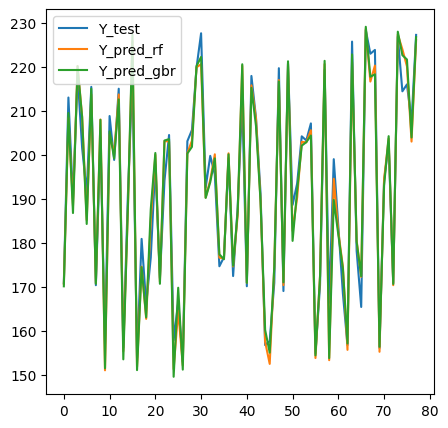

In [48]:
res.plot()

# LSTM

## Imp implementation details for RNN / LSTM

inputs are processed sequentially and not all together

Ex. if there are 5 features X t-1, X t-2, x t-3, x t-4 , x t-5

here , we don't give all 5 features at once

first x t-1 goes then x t-2 .... one by one

So, to achieve this LSTM input need to be in form of a queue / sequence and not as simple array

ex. [1,2,3,4] --> this will not work

[[1], [2], [3], [4]]  --> like this we can access one value at a time

In [49]:
import tensorflow as tf
from tensorflow import keras

In [50]:
X_train.shape,X_test.shape,Y_train.shape,Y_test.shape

((179, 5), (78, 5), (179,), (78,))

- LSTM - RNN --> takes 3 Dimensional inputs

In [51]:
X_train[:3].values

array([[178.58, 179.55, 180.94, 174.24, 174.62],
       [192.74, 194.15, 194.19, 194.81, 192.58],
       [166.52, 166.44, 165.25, 154.68, 156.3 ]])

In [52]:
# reshape the training features and test features to suit input format of RNN / LSTM
# here we add extra dim to X_train and X_test
import numpy as np
X_train = np.reshape(X_train.values, (X_train.shape[0],X_train.shape[1], 1))

In [53]:
X_train.shape #x_input = [[[1],[2],[3.3],[4],[5]]] -> 1 * 5 * 1

(179, 5, 1)

In [54]:
X_train[:3]

array([[[178.58],
        [179.55],
        [180.94],
        [174.24],
        [174.62]],

       [[192.74],
        [194.15],
        [194.19],
        [194.81],
        [192.58]],

       [[166.52],
        [166.44],
        [165.25],
        [154.68],
        [156.3 ]]])

## LSTM with single neuron

Lets check power of a single neuron of LSTM

In [55]:
model = keras.Sequential()

# Adding LSTM layers
model.add(keras.layers.LSTM(units=4,
                            return_sequences = False,
                            input_shape= (X_train.shape[1],X_train.shape[2])))
# Adding the output layer
model.add( keras.layers.Dense(1, activation='linear'))

# Compiling the LSTM
model.compile(optimizer = 'adam',
              loss = 'mean_squared_error',
              metrics=['mae'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [56]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 4)              │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101 (404.00 B)

 Trainable params: 101 (404.00 B)

 Non-trainable params: 0 (0.00 B)

In [57]:
history = model.fit(X_train, Y_train,
                    validation_split=0.1,
                    epochs = 100, batch_size = 5)

Epoch 1/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 37568.8477 - mae: 192.6217 - val_loss: 35295.3086 - val_mae: 186.4763
Epoch 2/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 37546.5742 - mae: 192.5639 - val_loss: 35273.7305 - val_mae: 186.4184
Epoch 3/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 37524.2734 - mae: 192.5062 - val_loss: 35252.1445 - val_mae: 186.3606
Epoch 4/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 37501.9023 - mae: 192.4482 - val_loss: 35230.5625 - val_mae: 186.3026
Epoch 5/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 37479.5977 - mae: 192.3900 - val_loss: 35208.8398 - val_mae: 186.2443
Epoch 6/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 37457.2188 - mae: 192.3317 - val_loss: 35187.1953 - val_mae: 186.1862
Epoch 7/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 37434.8398 - mae: 192.2737 - val_loss: 35165.6055 - val_mae: 186.1282
Epoch 8/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 37412.5078 - mae: 192.2153 - val_loss

In [58]:
# history = model.fit(X_train, Y_train, validation_split=0.3,epochs = 10, batch_size = 10)

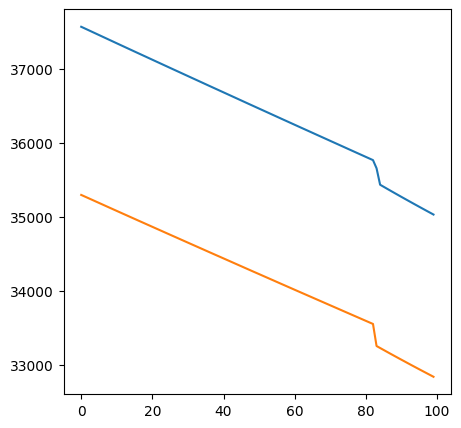

In [59]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

# Multi layer LSTM

HL 1 --> 10 LSTM neurons

HL 2 --> 5

Output Layer --> dense layer 1 neuron activation => linear

In [60]:
model = keras.Sequential()
# return_sequences = True, --> hidden state output should be parsed to next state
# Adding LSTM layers
model.add(keras.layers.LSTM(units=10,
                            return_sequences = True,
                            input_shape= (X_train.shape[1],X_train.shape[2])))

model.add(keras.layers.LSTM(units=5,
                            return_sequences = False))
# Adding the output layer
model.add( keras.layers.Dense(1, activation='linear'))

# Compiling the LSTM
model.compile(optimizer = 'adam', loss = 'mean_squared_error', metrics=['mae'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [61]:
history = model.fit(X_train, Y_train,
                    validation_split=0.3,
                    epochs = 100, batch_size = 10)

Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - loss: 37379.4102 - mae: 192.0721 - val_loss: 37806.5156 - val_mae: 193.2948
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 37337.8086 - mae: 191.9638 - val_loss: 37763.1211 - val_mae: 193.1825
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 37293.8125 - mae: 191.8486 - val_loss: 37717.1836 - val_mae: 193.0636
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 37246.1602 - mae: 191.7250 - val_loss: 37667.0000 - val_mae: 192.9336
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 37194.6641 - mae: 191.5908 - val_loss: 37613.3086 - val_mae: 192.7944
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 37139.8945 - mae: 191.4478 - val_loss: 37556.5977 - val_mae: 192.6472
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 37082.1875 - mae: 191.2971 - val_loss: 37495.7852 - val_mae: 192.4892
Epoch 8/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 37012.3945 - mae: 191.1149 - v

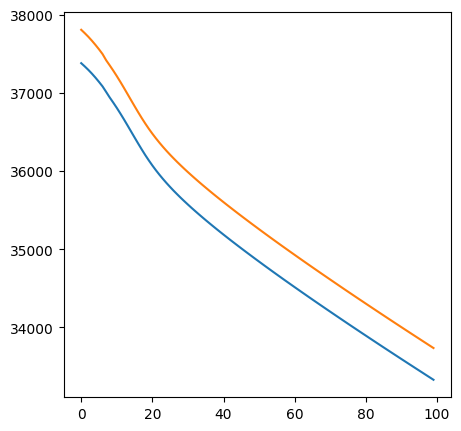

In [62]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

5. Create following LSTM NN and train using learning rate 0.0001 and epochs=5

	a. Use single LSTM layer with 1 neuron + output layer (dense) with 1 neuron and linear activation
	b. Use single LSTM layer with 10 neuron + output layer (dense) with 1 neuron and linear activation
	c. LSTM layer with 10 neuron + LSTM layer with 5 neuron + output layer (dense) with 1 neuron and linear activation

In [63]:
from tensorflow.keras.optimizers import Adam
model = keras.Sequential()

# Adding LSTM layers
model.add(keras.layers.LSTM(units=1,
                            return_sequences = False,
                            input_shape= (X_train.shape[1],X_train.shape[2])))
# Adding the output layer
model.add( keras.layers.Dense(1, activation='linear'))

# Compiling the LSTM
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss = 'mean_squared_error',
              metrics=['mae'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [64]:
history = model.fit(X_train, Y_train,
                    validation_split=0.3,
                    epochs = 100, batch_size = 10)

Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - loss: 37011.8398 - mae: 191.1131 - val_loss: 37458.9023 - val_mae: 192.3935
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 37010.8438 - mae: 191.1105 - val_loss: 37457.8984 - val_mae: 192.3909
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 37009.8516 - mae: 191.1079 - val_loss: 37456.8984 - val_mae: 192.3883
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 37008.8594 - mae: 191.1053 - val_loss: 37455.9023 - val_mae: 192.3857
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 37007.8633 - mae: 191.1027 - val_loss: 37454.9023 - val_mae: 192.3831
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 37006.8672 - mae: 191.1001 - val_loss: 37453.9023 - val_mae: 192.3805
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 37005.8789 - mae: 191.0975 - val_loss: 37452.8984 - val_mae: 192.3779
Epoch 8/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 37004.8789 - mae: 191.0949 - val_los

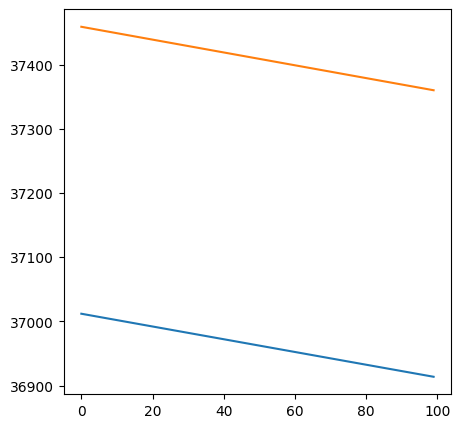

In [65]:

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

In [66]:
# 5 b)
b = keras.Sequential()

# Adding LSTM layers
b.add(keras.layers.LSTM(units=10,
                            return_sequences = False,
                            input_shape= (X_train.shape[1],X_train.shape[2])))
b.add( keras.layers.Dense(1, activation='linear'))

# Compiling the LSTM
b.compile(optimizer=Adam(learning_rate=0.0001),
              loss = 'mean_squared_error',
              metrics=['mae'])
#

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [67]:
history = b.fit(X_train, Y_train,
                    validation_split=0.3,
                    epochs = 100, batch_size = 10)

Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 37230.8047 - mae: 191.6844 - val_loss: 37675.8594 - val_mae: 192.9558
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 37222.5625 - mae: 191.6627 - val_loss: 37666.8398 - val_mae: 192.9323
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 37212.9258 - mae: 191.6374 - val_loss: 37656.2656 - val_mae: 192.9048
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 37201.6133 - mae: 191.6079 - val_loss: 37643.8867 - val_mae: 192.8728
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 37188.5000 - mae: 191.5737 - val_loss: 37629.7070 - val_mae: 192.8361
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 37173.7227 - mae: 191.5352 - val_loss: 37613.9180 - val_mae: 192.7952
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 37157.3789 - mae: 191.4928 - val_loss: 37596.6484 - val_mae: 192.7505
Epoch 8/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 37139.6133 - mae: 191.4465 - val_los

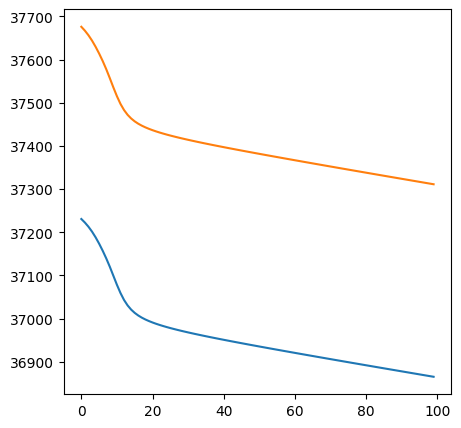

In [68]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

In [69]:
# 5 c)
c = keras.Sequential()

# Adding LSTM Layer
c.add(keras.layers.LSTM(units=10,
                            return_sequences = True,
                            input_shape= (X_train.shape[1],X_train.shape[2])))
c.add(keras.layers.LSTM(units=5,
                            return_sequences = False))

c.add( keras.layers.Dense(1, activation='linear'))

# Compiling the LSTM
c.compile(optimizer=Adam(learning_rate=0.0001),
              loss = 'mean_squared_error',
              metrics=['mae'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [70]:
history = c.fit(X_train, Y_train,
                    validation_split=0.3,
                    epochs = 100, batch_size = 10)

Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 67ms/step - loss: 37469.7305 - mae: 192.3074 - val_loss: 37917.1562 - val_mae: 193.5808
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 37463.8945 - mae: 192.2921 - val_loss: 37911.2500 - val_mae: 193.5655
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 37458.0547 - mae: 192.2769 - val_loss: 37905.3711 - val_mae: 193.5503
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 37452.2031 - mae: 192.2617 - val_loss: 37899.5078 - val_mae: 193.5352
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 37446.3828 - mae: 192.2466 - val_loss: 37893.6445 - val_mae: 193.5200
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 37440.5547 - mae: 192.2315 - val_loss: 37887.7930 - val_mae: 193.5049
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 37434.7305 - mae: 192.2163 - val_loss: 37881.9414 - val_mae: 193.4898
Epoch 8/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 37428.9219 - mae: 192.2012 - v

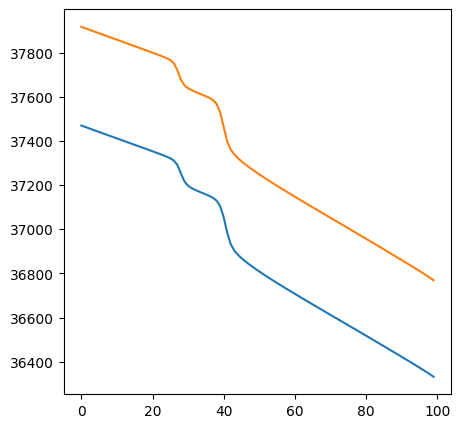

In [71]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.show()

6. Create 15 lag columns as features and Split the data in train and test  
then, Create following LSTM NN and train using learning rate 0.0001 and epochs=5

	a. Use single LSTM layer with 1 neuron + output layer (dense) with 1 neuron and linear activation
	b. Use single LSTM layer with 10 neuron + output layer (dense) with 1 neuron and linear activation
	c. LSTM layer with 10 neuron + LSTM layer with 5 neuron + output layer (dense) with 1 neuron and linear activation


In [72]:
ts_new = df_new[['close']].copy()
ts_new.shape

(262, 1)

In [73]:
for i in range(1,16):
  ts_new['close_t_'+str(i)] = ts_new['close'].shift(i) # shift one value below

In [74]:
ts_new.dropna(inplace=True)

In [75]:
Y = ts_new['close']
X = ts_new.drop('close',axis=1)
X.shape, Y.shape

((247, 15), (247,))

In [76]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y, test_size=0.3, random_state=7)
X_train.shape,X_test.shape,Y_train.shape,Y_test.shape

((172, 15), (75, 15), (172,), (75,))

In [77]:
print(X_train[:3].values)
X_train = np.reshape(X_train.values, (X_train.shape[0],X_train.shape[1], 1))

[[223.77 224.29 227.99 232.07 229.28 227.26 225.74 224.95 220.42 222.19
  220.79 217.66 220.03 218.37 218.24]
 [174.62 172.29 176.78 176.78 176.98 185.86 193.53 191.41 186.8  192.23
  194.17 204.47 208.49 209.95 203.77]
 [198.95 200.62 199.5  200.1  197.   195.69 195.35 194.02 191.24 189.95
  188.72 188.47 186.79 188.74 191.05]]


In [78]:
X_train[:3]

array([[[223.77],
        [224.29],
        [227.99],
        [232.07],
        [229.28],
        [227.26],
        [225.74],
        [224.95],
        [220.42],
        [222.19],
        [220.79],
        [217.66],
        [220.03],
        [218.37],
        [218.24]],

       [[174.62],
        [172.29],
        [176.78],
        [176.78],
        [176.98],
        [185.86],
        [193.53],
        [191.41],
        [186.8 ],
        [192.23],
        [194.17],
        [204.47],
        [208.49],
        [209.95],
        [203.77]],

       [[198.95],
        [200.62],
        [199.5 ],
        [200.1 ],
        [197.  ],
        [195.69],
        [195.35],
        [194.02],
        [191.24],
        [189.95],
        [188.72],
        [188.47],
        [186.79],
        [188.74],
        [191.05]]])

In [79]:
# 6 a)
model = keras.Sequential()

# Adding LSTM layers
model.add(keras.layers.LSTM(units=1,
                            return_sequences = False,
                            input_shape= (X_train.shape[1],X_train.shape[2])))
# Adding the output layer
model.add(keras.layers.Dense(1, activation='linear'))

# Compiling the LSTM
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss = 'mean_squared_error',
              metrics=['mae'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [80]:
history = model.fit(X_train, Y_train,
                    validation_split=0.3,
                    epochs = 100, batch_size = 10)

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 37235.5156 - mae: 191.8747 - val_loss: 37281.3281 - val_mae: 191.8292
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 37235.0586 - mae: 191.8735 - val_loss: 37280.8672 - val_mae: 191.8280
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 37234.6016 - mae: 191.8723 - val_loss: 37280.4102 - val_mae: 191.8268
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 37234.1328 - mae: 191.8711 - val_loss: 37279.9531 - val_mae: 191.8256
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 37233.6836 - mae: 191.8699 - val_loss: 37279.4922 - val_mae: 191.8244
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 37233.2227 - mae: 191.8687 - val_loss: 37279.0352 - val_mae: 191.8232
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 37232.7578 - mae: 191.8675 - val_loss: 37278.5703 - val_mae: 191.8220
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 37232.2969 - mae: 191.8663 - v

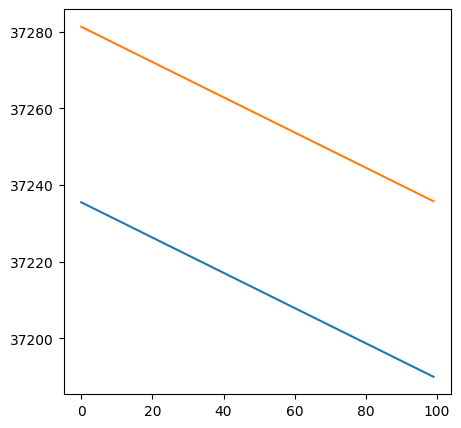

In [81]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.show()

In [82]:
# 6 b)
b = keras.Sequential()

# Adding LSTM layers
b.add(keras.layers.LSTM(units=10,
                            return_sequences = False,
                            input_shape= (X_train.shape[1],X_train.shape[2])))
b.add( keras.layers.Dense(1, activation='linear'))

# Compiling the LSTM
b.compile(optimizer=Adam(learning_rate=0.0001),
              loss = 'mean_squared_error',
              metrics=['mae'])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [83]:
history = b.fit(X_train, Y_train,
                    validation_split=0.3,
                    epochs = 100, batch_size = 10)

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 37261.1992 - mae: 191.9416 - val_loss: 37306.8203 - val_mae: 191.8956
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 37260.3867 - mae: 191.9395 - val_loss: 37306.0000 - val_mae: 191.8935
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 37259.5742 - mae: 191.9373 - val_loss: 37305.1953 - val_mae: 191.8914
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 37258.7656 - mae: 191.9353 - val_loss: 37304.3789 - val_mae: 191.8893
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 37257.9531 - mae: 191.9332 - val_loss: 37303.5703 - val_mae: 191.8871
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 37257.1406 - mae: 191.9310 - val_loss: 37302.7578 - val_mae: 191.8850
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 37256.3359 - mae: 191.9289 - val_loss: 37301.9453 - val_mae: 191.8829
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 37255.5195 - mae: 191.9268 - v

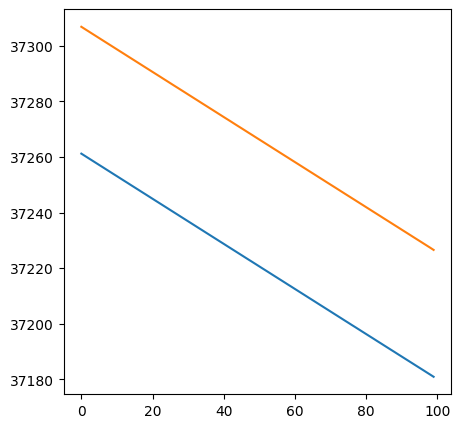

In [84]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.show()

In [85]:
# 6 c)
c = keras.Sequential()

# Adding LSTM Layer
c.add(keras.layers.LSTM(units=10,
                            return_sequences = True,
                            input_shape= (X_train.shape[1],X_train.shape[2])))
c.add(keras.layers.LSTM(units=5,
                            return_sequences = False))

c.add( keras.layers.Dense(1, activation='linear'))

# Compiling the LSTM
c.compile(optimizer=Adam(learning_rate=0.0001),
              loss = 'mean_squared_error',
              metrics=['mae'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [86]:
history = c.fit(X_train, Y_train,
                    validation_split=0.3,
                    epochs = 100, batch_size = 10)

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - loss: 37177.1680 - mae: 191.7224 - val_loss: 37214.4336 - val_mae: 191.6546
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 37161.3164 - mae: 191.6811 - val_loss: 37199.8086 - val_mae: 191.6163
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 37146.9102 - mae: 191.6433 - val_loss: 37185.0234 - val_mae: 191.5778
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 37131.8242 - mae: 191.6043 - val_loss: 37169.5898 - val_mae: 191.5378
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 37116.4219 - mae: 191.5645 - val_loss: 37154.3281 - val_mae: 191.4982
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 37101.6250 - mae: 191.5259 - val_loss: 37139.8281 - val_mae: 191.4605
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 37087.6953 - mae: 191.4897 - val_loss: 37126.4375 - val_mae: 191.4257
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 37074.7539 - mae: 191.4561 - v

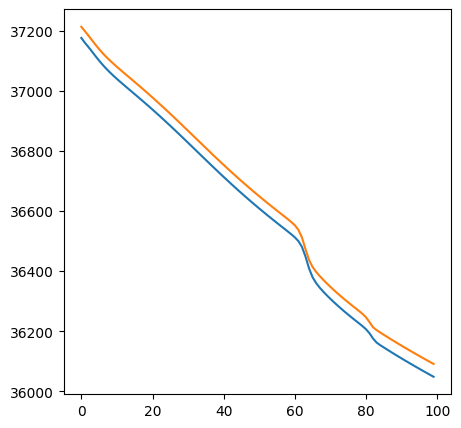

In [87]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.show()

In [88]:
import numpy as np
test_data =  np.array([ [[200.99], 	[203.43], 	[199.04], 	[197.00], 	[193.34]] ])

In [89]:
test_data.shape

(1, 5, 1)

In [90]:
model.predict(test_data)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step


array([[0.1199144]], dtype=float32)